In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error,accuracy_score
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [15]:
df=pd.read_csv(r"G:\MSIS\Projects\Regression\House_price_prediction\housing.csv")

In [16]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [17]:
df.shape

(5000, 7)

In [18]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.size

35000

In [21]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

In [22]:
X=df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms','Avg. Area Number of Bedrooms', 'Area Population']]
y=df['Price']

In [23]:
X.shape

(5000, 5)

In [24]:
y.shape

(5000,)

In [25]:
X.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039
std,10657.991214,0.991456,1.005833,1.234137,9925.650114
min,17796.631190,2.644304,3.236194,2.000000,172.610686
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770
max,107701.748400,9.519088,10.759588,6.500000,69621.713380


In [26]:
corr=X.corr()
print(corr)

                              Avg. Area Income  Avg. Area House Age  \
Avg. Area Income                      1.000000            -0.002007   
Avg. Area House Age                  -0.002007             1.000000   
Avg. Area Number of Rooms            -0.011032            -0.009428   
Avg. Area Number of Bedrooms          0.019788             0.006149   
Area Population                      -0.016234            -0.018743   

                              Avg. Area Number of Rooms  \
Avg. Area Income                              -0.011032   
Avg. Area House Age                           -0.009428   
Avg. Area Number of Rooms                      1.000000   
Avg. Area Number of Bedrooms                   0.462695   
Area Population                                0.002040   

                              Avg. Area Number of Bedrooms  Area Population  
Avg. Area Income                                  0.019788        -0.016234  
Avg. Area House Age                               0.006149    

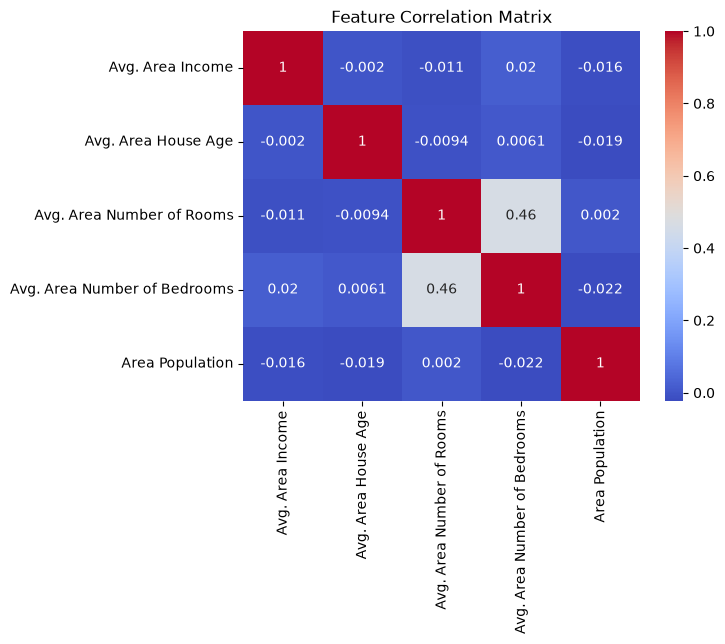

In [27]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

X_vif = sm.add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif)

                        Feature         VIF
0                         const  143.857530
1              Avg. Area Income    1.001159
2           Avg. Area House Age    1.000577
3     Avg. Area Number of Rooms    1.273535
4  Avg. Area Number of Bedrooms    1.274413
5               Area Population    1.001266


In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
X_train.shape

(4000, 5)

In [31]:
X_train.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
4227,66547.01645,5.846095,6.847298,4.13,27850.82290
4676,53722.00860,6.401391,7.787764,3.30,47649.22466
800,64838.49290,6.437157,8.699544,4.02,32921.01007
3671,67097.09212,6.086754,7.211963,3.05,27191.50688
4193,75245.46544,8.167820,7.420100,3.42,37410.66993


In [32]:
X_test.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
1501,61907.59335,7.017838,6.440256,3.25,43828.94721
2586,57160.20224,6.893260,6.921532,3.13,43467.14704
2653,70190.79644,6.745054,6.662567,2.01,29215.13611
1055,69316.79689,6.300409,7.873576,4.28,24448.21146
705,72991.48165,3.412866,6.494081,2.48,50626.49543


In [33]:
scaler=StandardScaler()

In [34]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [35]:
X_train[:10]

array([[-0.19049242, -0.12817719, -0.13160635,  0.12038585, -0.82761782],
       [-1.38876401,  0.43080443,  0.80028487, -0.55648895,  1.15829878],
       [-0.35012392,  0.46680752,  1.70375078,  0.03067955, -0.31904298],
       [-0.13909751,  0.11407909,  0.22973349, -0.7603669 , -0.89375177],
       [ 0.62222478,  2.20895742,  0.43597233, -0.45862753,  0.13130094],
       [-0.79944608, -0.26026485,  1.0011855 ,  1.65354806, -0.32936887],
       [-1.66233229,  0.75629896,  1.01342183,  1.70247876,  0.38537518],
       [-0.38588179,  0.18021673,  0.44161664,  1.75956459, -0.7057053 ],
       [-0.28211782,  2.1234527 ,  0.31969389,  1.76771971, -0.60028734],
       [-0.25020225, -0.47011415, -1.24148931, -0.48309289, -0.28067228]])

In [36]:
X_test[:10]

array([[-0.63648563,  1.04320356, -0.5834105 , -0.57494926,  0.76163338],
       [-1.08987422,  0.91646744, -0.09783197, -0.66983451,  0.72448642],
       [ 0.1545825 ,  0.76569332, -0.35911229, -1.55543016, -0.73880446],
       [ 0.0711132 ,  0.31334465,  0.86272207,  0.23948246, -1.22823697],
       [ 0.42205545, -2.62422707, -0.52910417, -1.18379627,  1.45955526],
       [ 0.96092859, -0.53613825,  0.51722818, -0.58285636,  0.75135136],
       [-1.44721345,  0.34780533,  1.41814645,  0.02599065, -0.29139727],
       [-0.83137276, -0.12418583, -1.12942751,  0.14459721, -0.44624292],
       [-1.60676215,  0.66751562, -0.81300035,  0.34227481, -0.68392733],
       [ 1.06175551, -0.07676159, -0.23643865, -0.42471428,  0.1953819 ]])

In [37]:
y_train[:10]

4227    1.094880e+06
4676    1.300389e+06
800     1.382172e+06
3671    1.027428e+06
4193    1.562887e+06
2968    1.005087e+06
4793    1.156980e+06
4368    1.095728e+06
2776    1.357576e+06
2970    6.984577e+05
Name: Price, dtype: float64

In [38]:
type(X_test)

numpy.ndarray

In [39]:
type(y_train)

pandas.Series

In [40]:
model=LinearRegression()

In [41]:
regressor=model.fit(X_train,y_train)

In [42]:
print("The slope1 (b1) of the model is :", regressor.coef_[0])
print("The slope2 (b2) of the model is :", regressor.coef_[1])
print("The slope3 (b3) of the model is :", regressor.coef_[2])
print("The slope4 (b4) of the model is :", regressor.coef_[3])
print("The slope5 (b5) of the model is :", regressor.coef_[4])
print("The intercept (b0) of the model is :",regressor.intercept_)

The slope1 (b1) of the model is : 231741.8766538643
The slope2 (b2) of the model is : 163580.77656518092
The slope3 (b3) of the model is : 120724.77138500882
The slope4 (b4) of the model is : 2992.4491360469547
The slope5 (b5) of the model is : 152235.9000985402
The intercept (b0) of the model is : 1229576.9925630253


In [43]:
y_pred=regressor.predict(X_test)

In [44]:
y_pred

array([1296520.00584686, 1223401.60570162, 1230172.08200336,
       1215200.86307236, 1052890.09155478, 1539643.21286693,
       1078013.35346046,  812747.32448324,  765172.30518943,
       1463002.6879827 ,  649686.40171427, 1604656.41571708,
        985512.31883927, 1791361.8528032 , 1279198.15325349,
       1071014.94805569, 1412141.85872325, 1064247.96305678,
        781986.39808493,  913515.54016366, 1121251.35742177,
        898165.88654283, 1483807.59098775, 1272262.23359233,
       1577377.16292733, 1117849.93471088, 1072917.13931953,
        957189.36770906,  905381.11825197, 1738774.53298374,
       1273924.10685733, 1616488.33920996, 1426287.46676627,
       1221581.90849698, 1477647.17602497, 1718182.19034825,
       1535670.30094021,  753516.01069065, 1764856.55907799,
       1163299.00017742, 1549593.27960173,  878585.65243298,
       1359336.32637012,  825798.99827349, 1188068.1546608 ,
       1120259.35561014, 1351251.87162651, 1439099.38439396,
       1567982.37598915,

In [45]:
print("mean_squared_error of the model is :",mean_squared_error(y_pred,y_test))
print("mean_absolute_error of the model is :",mean_absolute_error(y_pred,y_test))
print("root_mean_squared_error of the model is :",root_mean_squared_error(y_pred,y_test))
print("r2_score of the model is :",r2_score(y_pred,y_test))

mean_squared_error of the model is : 10325225810.33962
mean_absolute_error of the model is : 81539.13071562961
root_mean_squared_error of the model is : 101613.11829847375
r2_score of the model is : 0.912495389787624


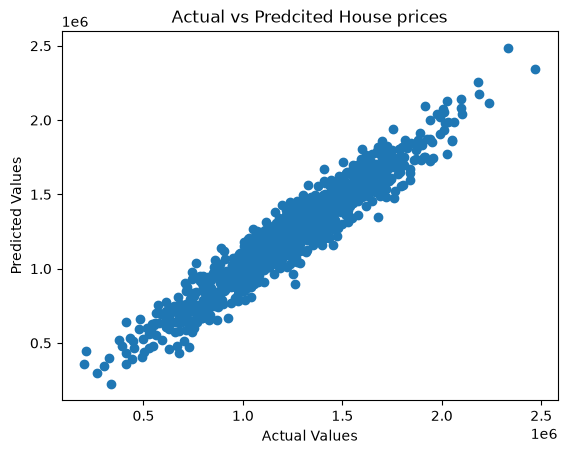

In [46]:
plt.scatter(y_test,y_pred,colorizer='green')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predcited House prices')
plt.show()

In [47]:
residuals=y_test-y_pred

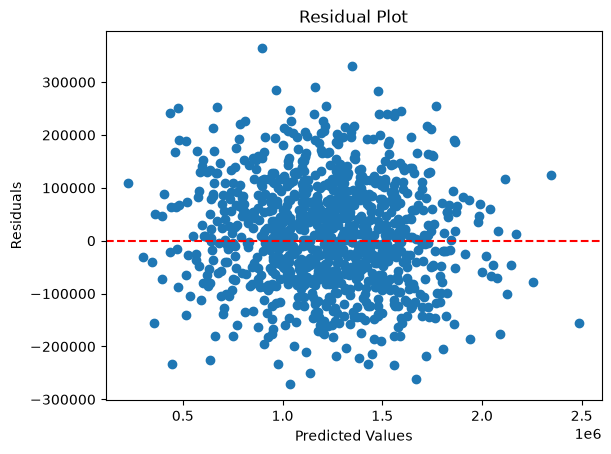

In [48]:
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red',linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [49]:
unseen_data=[[65000, 6.2, 7.5, 4.0, 30000]]
scaled_data=scaler.transform(unseen_data)
prediction=regressor.predict(scaled_data)
print(prediction[0])

1143563.541278111


c:\Users\mayur\anaconda3\envs\eda_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


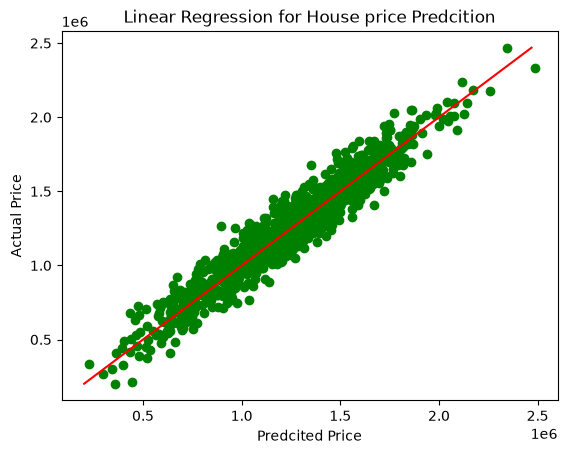

In [54]:
#Plotting the regression line
plt.scatter(y_pred,y_test,color='green')
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color='red'
)

plt.xlabel('Predcited Price')
plt.ylabel('Actual Price')
plt.title('Linear Regression for House price Predcition')
plt.show()